# NHANES project about General Oral Health and Geriatric Nutrition Risk Index (GNRI): descriptive and regression analysis
> This notebook has the purpose to collect all the analysis on Nhanes dataset for a medical paper project 

Requirements and Information:
1. Nhanes dataset from 2009/10 to 2013/14
2. Outcome:
    - Geriatric Nutrition Risk Index (GNRI)
3. Exposure/Predictor:
    1. OHQ835 : {Do you/Does SP} think {you/s/he} might have gum disease?
    2. OHQ845 : Overall, how would {you/SP} rate the health of {your/his/her} teeth and gums?
    3. OHQ850 : Ever had treatment for gum disease?
    4. OHQ855 : Any teeth became loose without an injury
    5. OHQ860 : Ever been told of bone loss around teeth
    6. OHQ865 : Noticed a tooth that doesn't look right
    7. OHQ870 : How many days use dental floss/device
    8. OHQ875 : Days used mouthwash for dental problem
4. Confounding Variables:
    - Gender (RIAGENDR)
    - Age at screening (RIDAGEYR)
    - Race (RIDRETH1)
    - Education	(DMDEDUC2)
    - Poverty income ratio (INDFMPIR)
    - Smoking status (SMQ020)
5. Mediators:
    - Heart failure	(RIDRETH1)  
    - Coronary heart disease (MCQ160b)
    - Stroke (MCQ160c)
    - Liver disease	(MCQ160o)
    - Cancer (MCQ500)
    - Diabetes (MCQ220)
    - High blood pressure (DIQ010)
6. Age => 60

## NHANES 2013/14: Geriatric Nutrition Risk Index (GNRI) and Global Oral Health

### Import Libraries

In [15]:
library(haven)
library(nhanesA)
library(survey)
library(MASS)
library(dplyr)
library(tidyr)
library(tidyverse)
library(ggplot2)
library(readr)
library(flextable)
library(officer)
library(nnet)
library(broom)
library(ggplot2)
library(patchwork)
library(psych)


Attaching package: 'patchwork'


The following object is masked from 'package:MASS':

    area




### Configurations

In [2]:
path_to_data_09_10 <- "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/2009_10/"
path_to_data_11_12 <- "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/2011_12/"
path_to_data_13_14 <- "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/2013_14/"

### Load Dataset & Feature Selection

In [3]:
# Datasets for 2009/10 period

demo_09_10 <- read_xpt(file.path(path_to_data_09_10, "DEMO_F.xpt"))

demo_09_10_selected <- demo_09_10 %>%
  select(SEQN, RIAGENDR, RIDAGEYR, RIDRETH1, DMDEDUC2, INDFMPIR)

alcohol_09_10 <- read_xpt(file.path(path_to_data_09_10, "ALQ_F.xpt"))

alcohol_09_10_selected <- alcohol_09_10 %>%
  select(SEQN, ALQ101)

smoking_09_10 <- read_xpt(file.path(path_to_data_09_10, "SMQ_F.xpt.txt"))

smoking_09_10_selected <- smoking_09_10 %>%
    select(SEQN, SMQ020)

med_conditions_09_10 <- read_xpt(file.path(path_to_data_09_10, "MCQ_F.xpt"))

med_conditions_09_10_selected <- med_conditions_09_10 %>%
    select(SEQN, MCQ140, MCQ160B, MCQ160C, MCQ160D, MCQ160E, MCQ160F, MCQ160L, MCQ220)

med_conditions_09_10_selected <- med_conditions_09_10_selected %>%
  rename(DLQ020 = MCQ140)


blood_pressure_09_10 <- read_xpt(file.path(path_to_data_09_10, "BPQ_F.xpt"))

blood_pressure_09_10_selected <- blood_pressure_09_10 %>%
    select(SEQN, BPQ020)


diabetes_09_10 <- read_xpt(file.path(path_to_data_09_10, "DIQ_F.xpt"))

diabetes_09_10_selected <- diabetes_09_10 %>%
    select(SEQN, DIQ010)


oral_09_10 <- read_xpt(file.path(path_to_data_09_10, "OHQ_F.xpt"))

selected_cols <- c(
  "OHQ835",
  "OHQ845",
  "OHQ850",
  "OHQ855",
  "OHQ860",
  "OHQ865",
  "OHQ870",
  "OHQ875"
)
oral_09_10_selected <- oral_09_10 %>%
    select(SEQN, all_of(selected_cols))


albumin_09_10 <- read_xpt(file.path(path_to_data_09_10, "BIOPRO_F.xpt.txt"))

albumin_09_10_selected <- albumin_09_10 %>%
    select(SEQN, LBDSALSI)

w_h_09_10 <- read_xpt(file.path(path_to_data_09_10, "BMX_F.xpt"))

w_h_09_10_selected <- w_h_09_10 %>%
    select(SEQN, BMXWT, BMXHT)

In [4]:
# Datasets for 2011/12 period

demo_11_12 <- read_xpt(file.path(path_to_data_11_12, "DEMO_G.xpt.txt"))

demo_11_12_selected <- demo_11_12 %>%
  select(SEQN, RIAGENDR, RIDAGEYR, RIDRETH1, DMDEDUC2, INDFMPIR)

alcohol_11_12 <- read_xpt(file.path(path_to_data_11_12, "ALQ_G.xpt.txt"))

alcohol_11_12_selected <- alcohol_11_12 %>%
  select(SEQN, ALQ101)


smoking_11_12 <- read_xpt(file.path(path_to_data_11_12, "SMQ_G.xpt.txt"))

smoking_11_12_selected <- smoking_11_12 %>%
    select(SEQN, SMQ020)


med_conditions_11_12 <- read_xpt(file.path(path_to_data_11_12, "MCQ_G.xpt.txt"))

med_conditions_11_12_selected <- med_conditions_11_12 %>%
    select(SEQN, MCQ140, MCQ160B, MCQ160C, MCQ160D, MCQ160E, MCQ160F, MCQ160L, MCQ220)

med_conditions_11_12_selected <- med_conditions_11_12_selected %>%
  rename(DLQ020 = MCQ140)


blood_pressure_11_12 <- read_xpt(file.path(path_to_data_11_12, "BPQ_G.xpt.txt"))

blood_pressure_11_12_selected <- blood_pressure_11_12 %>%
    select(SEQN, BPQ020)


diabetes_11_12 <- read_xpt(file.path(path_to_data_11_12, "DIQ_G.xpt.txt"))

diabetes_11_12_selected <- diabetes_11_12 %>%
    select(SEQN, DIQ010)


oral_11_12 <- read_xpt(file.path(path_to_data_11_12, "OHQ_G.xpt.txt"))

selected_cols <- c(
  "OHQ835",
  "OHQ845",
  "OHQ850",
  "OHQ855",
  "OHQ860",
  "OHQ865",
  "OHQ870",
  "OHQ875"
)
oral_11_12_selected <- oral_11_12 %>%
    select(SEQN, all_of(selected_cols))


albumin_11_12 <- read_xpt(file.path(path_to_data_11_12, "BIOPRO_G.xpt.txt"))

albumin_11_12_selected <- albumin_11_12 %>%
    select(SEQN, LBDSALSI)

w_h_11_12 <- read_xpt(file.path(path_to_data_11_12, "BMX_G.xpt.txt"))

w_h_11_12_selected <- w_h_11_12 %>%
    select(SEQN, BMXWT, BMXHT)

In [5]:
# Datasets for 2013/14 period

demo_13_14 <- read_xpt(file.path(path_to_data_13_14, "DEMO_H.xpt.txt"))

demo_13_14_selected <- demo_13_14 %>%
    select(SEQN, RIAGENDR, RIDAGEYR, RIDRETH1, DMDEDUC2, INDFMPIR)


alcohol_13_14 <- read_xpt(file.path(path_to_data_13_14, "ALQ_H.xpt.txt"))

alcohol_13_14_selected <- alcohol_13_14 %>%
    select(SEQN, ALQ101)


smoking_13_14 <- read_xpt(file.path(path_to_data_13_14, "SMQ_H.xpt.txt"))

smoking_13_14_selected <- smoking_13_14 %>%
    select(SEQN, SMQ020)


med_conditions_13_14 <- read_xpt(file.path(path_to_data_13_14, "MCQ_H.xpt.txt"))

med_conditions_13_14_selected <- med_conditions_13_14 %>%
    select(SEQN, MCQ160B, MCQ160C, MCQ160D, MCQ160E, MCQ160F, MCQ160L, MCQ220)


blood_pressure_13_14 <- read_xpt(file.path(path_to_data_13_14, "BPQ_H.xpt.txt"))

blood_pressure_13_14_selected <- blood_pressure_13_14 %>%
    select(SEQN, BPQ020)


diabetes_13_14 <- read_xpt(file.path(path_to_data_13_14, "DIQ_H.xpt.txt"))

diabetes_13_14_selected <- diabetes_13_14 %>%
    select(SEQN, DIQ010)


oral_13_14 <- read_xpt(file.path(path_to_data_13_14, "OHQ_H.xpt.txt"))

selected_cols <- c(
  "OHQ835",
  "OHQ845",
  "OHQ850",
  "OHQ855",
  "OHQ860",
  "OHQ865",
  "OHQ870",
  "OHQ875"
)
oral_13_14_selected <- oral_13_14 %>%
  select(SEQN, all_of(selected_cols))


albumin_13_14 <- read_xpt(file.path(path_to_data_13_14, "BIOPRO_H.xpt.txt"))

albumin_13_14_selected <- albumin_13_14 %>%
    select(SEQN, LBDSALSI)

w_h_13_14 <- read_xpt(file.path(path_to_data_13_14, "BMX_H.xpt.txt"))

w_h_13_14_selected <- w_h_13_14 %>%
    select(SEQN, BMXWT, BMXHT)

### Merge datasets without NA and missing values
> Merge all data from each datasets and then exclude patients

In [6]:
# Merge datasets demographics and intrinsic capacity data

datasets_09_10 <- list(
  demo_09_10_selected, alcohol_09_10_selected, smoking_09_10_selected, med_conditions_09_10_selected,
  blood_pressure_09_10_selected, diabetes_09_10_selected,
  albumin_09_10_selected, w_h_09_10_selected, oral_09_10_selected
)

datasets_11_12 <- list(
  demo_11_12_selected, alcohol_11_12_selected, smoking_11_12_selected, med_conditions_11_12_selected,
  blood_pressure_11_12_selected, diabetes_11_12_selected,
  albumin_11_12_selected, w_h_11_12_selected, oral_11_12_selected
)

datasets_13_14 <- list(
  demo_13_14_selected, alcohol_13_14_selected, smoking_13_14_selected, med_conditions_13_14_selected,
  blood_pressure_13_14_selected, diabetes_13_14_selected,
  albumin_13_14_selected, w_h_13_14_selected, oral_13_14_selected
)

# Horizontal union for period 2009/10, 2011/12, 2013/14

df_09_10 <- Reduce(function(x, y) full_join(x, y, by = "SEQN"), datasets_09_10)

df_11_12 <- Reduce(function(x, y) full_join(x, y, by = "SEQN"), datasets_11_12)

df_13_14 <- Reduce(function(x, y) full_join(x, y, by = "SEQN"), datasets_13_14)

# Vertical union

df_final <- bind_rows(df_09_10, df_11_12, df_13_14)

print("Dimensions before removing NA values")
dim(df_final)

# Filter with AGE >= 60

df_final_age_60 <- subset(df_final, RIDAGEYR >= 60)

print("Dimensions with AGE >= 60")
dim(df_final_age_60)

# Excluding patients with missing values in features required for GNRI calculation (weight, height, albumin)

df_final_excluding_GNRI <- df_final_age_60[complete.cases(df_final_age_60[, c('BMXWT', 'BMXHT', 'LBDSALSI')]), ]

print("Dimensions without GNRI missing values")
dim(df_final_excluding_GNRI)

# Excluding patients with no examinations for Oral examination

df_final_excluding_oral <- df_final_excluding_GNRI[complete.cases(
  df_final_excluding_GNRI[, c(
                            "OHQ835",
                            "OHQ845",
                            "OHQ850",
                            "OHQ855",
                            "OHQ860",
                            "OHQ865",
                            "OHQ870",
                            "OHQ875"
                          )]), ]

df_final_excluding_oral <- df_final_excluding_oral %>%
  filter(!if_any(c(OHQ835, OHQ845, OHQ850, OHQ855, OHQ860,
                   OHQ865, OHQ870, OHQ875), ~ . == 9))

df_final_excluding_oral <- df_final_excluding_oral %>%
  filter(!if_any(c(OHQ835, OHQ845, OHQ850, OHQ855, OHQ860,
                   OHQ865), ~ . == 7))

df_final_excluding_oral <- df_final_excluding_oral %>%
  filter(!if_any(c(OHQ870, OHQ875), ~ . == 77))

df_final_excluding_oral <- df_final_excluding_oral %>%
  filter(!if_any(c(OHQ870, OHQ875), ~ . == 99))

print("Dimensions without complete Oral examination (missing values)")
dim(df_final_excluding_oral)

# Excluding patients with missing values in Confounding features

df_final_excluding_confounding <- df_final_excluding_oral[complete.cases(df_final_excluding_oral[, 
                                  c('RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'DMDEDUC2', 'INDFMPIR', 'ALQ101', 'SMQ020', 'MCQ160B',
                                  'MCQ160C', 'MCQ160D', 'MCQ160E', 'MCQ160F', 'MCQ160L', 'MCQ220', 'BPQ020', 'DIQ010')]), ]

df_final_merged <- df_final_excluding_confounding %>%
  filter(!if_any(c(DMDEDUC2, ALQ101, SMQ020, MCQ160B, MCQ160C, MCQ160D,
                   MCQ160E, MCQ160F, MCQ160L, MCQ220, BPQ020, DIQ010), ~ . == 9))

df_final_merged <- df_final_merged %>%
  filter(!if_any(c(DMDEDUC2, ALQ101, SMQ020, MCQ160B, MCQ160C, MCQ160D,
                   MCQ160E, MCQ160F, MCQ160L, MCQ220, BPQ020, DIQ010), ~ . == 7))

print("Dimensions without Confounding missing values")
dim(df_final_merged)

[1] "Dimensions before removing NA values"


[1] 30468    29

[1] "Dimensions with AGE >= 60"


[1] 5705   29

[1] "Dimensions without GNRI missing values"


[1] 5008   29

[1] "Dimensions without complete Oral examination (missing values)"


[1] 4627   29

[1] "Dimensions without Confounding missing values"


[1] 3898   29

In [7]:
# for cycle to see table for each categorical variable
categorical_vars <- c('RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'ALQ101', 'SMQ020', 
                      'MCQ160B', 'MCQ160C', 'MCQ160D', 'MCQ160E', 
                      'MCQ160F', 'MCQ160L', 'MCQ220',
                      'BPQ020', 'DIQ010')
for (var in categorical_vars) {
  print(paste("Table for", var))
  print(table(df_final_merged[[var]], useNA = "ifany"))
}

[1] "Table for RIAGENDR"

   1    2 
1923 1975 
[1] "Table for RIDRETH1"

   1    2    3    4    5 
 382  365 2062  793  296 
[1] "Table for DMDEDUC2"

   1    2    3    4    5 
 498  561  910 1068  861 
[1] "Table for ALQ101"

   1    2 
2624 1274 
[1] "Table for SMQ020"

   1    2 
1970 1928 
[1] "Table for MCQ160B"

   1    2 
 260 3638 
[1] "Table for MCQ160C"

   1    2 
 373 3525 
[1] "Table for MCQ160D"

   1    2 
 202 3696 
[1] "Table for MCQ160E"

   1    2 
 338 3560 
[1] "Table for MCQ160F"

   1    2 
 281 3617 
[1] "Table for MCQ160L"

   1    2 
 190 3708 
[1] "Table for MCQ220"

   1    2 
 802 3096 
[1] "Table for BPQ020"

   1    2 
2442 1456 
[1] "Table for DIQ010"

   1    2    3 
 893 2838  167 


In [9]:
# Saving preprocessed

write.csv(df_final_merged, "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/df_oral_health_GNRI_09_14.csv", row.names=FALSE)

### GNRI formula

In [10]:
df <- read.csv("/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/df_oral_health_GNRI_09_14.csv")

head(df)

,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,DMDEDUC2,INDFMPIR,ALQ101,SMQ020,DLQ020,MCQ160B,...,BMXWT,BMXHT,OHQ835,OHQ845,OHQ850,OHQ855,OHQ860,OHQ865,OHQ870,OHQ875
,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,...,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,51628,2,60,4,3,0.69,2,1,1,2,...,116.8,166.0,1,4,1,2,2,2,7,0
2,51633,1,80,3,4,1.27,1,1,1,2,...,79.1,174.3,2,2,2,2,2,2,5,6
3,51645,1,66,1,2,0.41,1,2,2,2,...,82.9,171.3,2,2,2,2,2,2,7,7
4,51654,1,66,3,4,2.20,1,1,2,2,...,68.0,169.5,2,2,1,2,1,2,7,7
5,51661,2,60,1,3,2.75,1,2,2,2,...,73.5,151.4,2,5,1,2,2,1,7,7
6,51669,2,65,1,1,0.54,2,2,1,2,...,73.1,162.0,2,3,1,2,2,2,0,0


In [11]:
calculate_gnri <- function(df) {
  df$ideal_weight <- ifelse(
    df$RIAGENDR == 1,
    0.75 * df$BMXHT - 62.5,
    0.60 * df$BMXHT - 40
  )

  # Weight ratio (bounded at 1)
  weight_ratio <- pmin(df$BMXWT / df$ideal_weight, 1)

  # GNRI
  df$gnri_score <- (1.489 * df$LBDSALSI) + (41.7 * weight_ratio)

  # Multi-class category
  df$gnri_category <- cut(
    df$gnri_score,
    breaks = c(-Inf, 82, 91, 98, Inf),
    labels = c("Severe risk", "Moderate risk", "Low risk", "No risk"),
    right = TRUE
  )

  # Binary category
  df$gnri_binary <- ifelse(df$gnri_score < 98, "Low-GNRI", "High-GNRI")

  return(df)
}

In [12]:
df_with_gnri <- calculate_gnri(df)

head(df_with_gnri[c("ideal_weight", "gnri_score", "gnri_category", "gnri_binary")])

,ideal_weight,gnri_score,gnri_category,gnri_binary
,<dbl>,<dbl>,<fct>,<chr>
1,59.600,99.771,No risk,High-GNRI
2,68.225,105.727,No risk,High-GNRI
3,65.975,107.216,No risk,High-GNRI
4,64.625,99.771,No risk,High-GNRI
5,50.840,101.260,No risk,High-GNRI
6,57.200,105.727,No risk,High-GNRI


In [13]:
table(df_with_gnri$gnri_binary)


High-GNRI  Low-GNRI 
     3529       369 

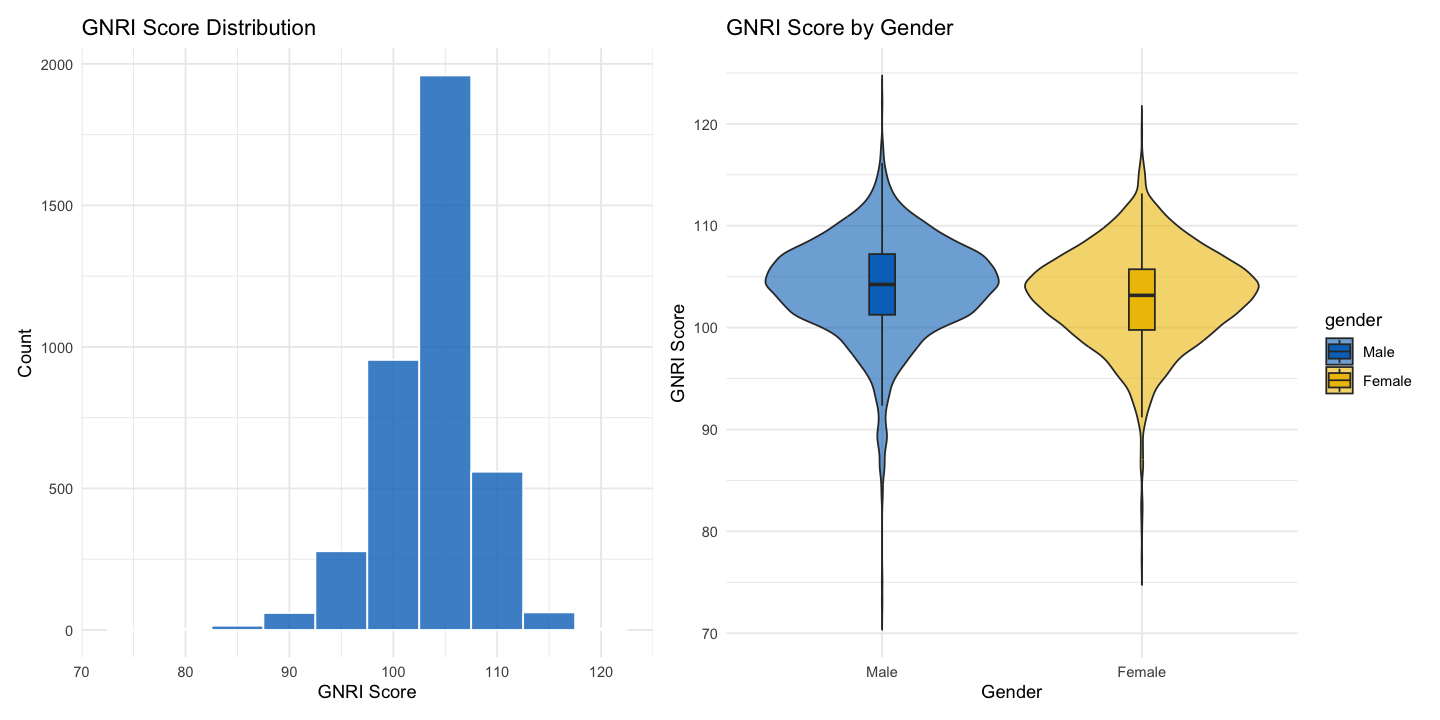

In [16]:
# Histogram and violin plot for GNRI score

options(repr.plot.width = 12, repr.plot.height = 6)

df_with_gnri$gender <- factor(df_with_gnri$RIAGENDR, levels = c(1, 2), labels = c("Male", "Female"))

hist_plot <- ggplot(df_with_gnri, aes(x = gnri_score)) +
  geom_histogram(binwidth = 5, fill = "#0073C2FF", color = "white", alpha = 0.8) +
  labs(title = "GNRI Score Distribution", x = "GNRI Score", y = "Count") +
  theme_minimal()

violin_plot <- ggplot(df_with_gnri, aes(x = gender, y = gnri_score, fill = gender)) +
  geom_violin(trim = FALSE, alpha = 0.6) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  labs(title = "GNRI Score by Gender", x = "Gender", y = "GNRI Score") +
  scale_fill_manual(values = c("Male" = "#0073C2FF", "Female" = "#EFC000FF")) +
  theme_minimal()

hist_plot + violin_plot

In [17]:
write.csv(df_with_gnri, "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/preprocessed_df_oral_health_GNRI_09_14.csv", row.names = FALSE)

### Descriptive Analysis

#### Loading DF & Weights

In [18]:
three_features = FALSE

if (three_features == TRUE) {
   df_path = "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/"
} else {
   df_path = "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/preprocessed_df_oral_health_GNRI_09_14.csv"
}

print(df_path)

df <- read.csv(df_path, 
              stringsAsFactors = TRUE)

head(df)

[1] "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/preprocessed_df_oral_health_GNRI_09_14.csv"


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,DMDEDUC2,INDFMPIR,ALQ101,SMQ020,DLQ020,MCQ160B,...,OHQ855,OHQ860,OHQ865,OHQ870,OHQ875,ideal_weight,gnri_score,gnri_category,gnri_binary,gender
,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<fct>,<fct>,<fct>
1,51628,2,60,4,3,0.69,2,1,1,2,...,2,2,2,7,0,59.600,99.771,No risk,High-GNRI,Female
2,51633,1,80,3,4,1.27,1,1,1,2,...,2,2,2,5,6,68.225,105.727,No risk,High-GNRI,Male
3,51645,1,66,1,2,0.41,1,2,2,2,...,2,2,2,7,7,65.975,107.216,No risk,High-GNRI,Male
4,51654,1,66,3,4,2.20,1,1,2,2,...,2,1,2,7,7,64.625,99.771,No risk,High-GNRI,Male
5,51661,2,60,1,3,2.75,1,2,2,2,...,2,2,1,7,7,50.840,101.260,No risk,High-GNRI,Female
6,51669,2,65,1,1,0.54,2,2,1,2,...,2,2,2,0,0,57.200,105.727,No risk,High-GNRI,Female


In [19]:
# Select weights

# Weights from Demographic datasets

demo_09_10 <- read_xpt(file.path(path_to_data_09_10, "DEMO_F.xpt"))

demo_09_10_weights <- demo_09_10 %>%
    select(SEQN, RIDAGEYR, WTMEC2YR, SDMVPSU, SDMVSTRA)

demo_11_12 <- read_xpt(file.path(path_to_data_11_12, "DEMO_G.xpt.txt"))

demo_11_12_weights <- demo_11_12 %>%
    select(SEQN, RIDAGEYR, WTMEC2YR, SDMVPSU, SDMVSTRA)

demo_13_14 <- read_xpt(file.path(path_to_data_13_14, "DEMO_H.xpt.txt"))

demo_13_14_weights <- demo_13_14 %>%
    select(SEQN, RIDAGEYR, WTMEC2YR, SDMVPSU, SDMVSTRA)

weights_09_10 <- list(
  demo_09_10_weights
)

weights_11_12 <- list(
  demo_11_12_weights
)

weights_13_14 <- list(
  demo_13_14_weights
)

# Horizontal union for period 2009/10, 2011/12, 2013/14

wt_09_10 <- Reduce(function(x, y) full_join(x, y, by = "SEQN"), weights_09_10)

wt_11_12 <- Reduce(function(x, y) full_join(x, y, by = "SEQN"), weights_11_12)

wt_13_14 <- Reduce(function(x, y) full_join(x, y, by = "SEQN"), weights_13_14)

# Vertical union

wt_final <- bind_rows(wt_09_10, wt_11_12, wt_13_14)

print("Dimensions before removing NA values")
dim(wt_final)

# Filter with AGE >= 60

wt_final_age_60 <- subset(wt_final, RIDAGEYR >= 60)

print("Dimensions with AGE >= 60")
dim(wt_final_age_60)

wt_final_age_60 <- subset(wt_final_age_60, select = -RIDAGEYR)
head(wt_final_age_60)

# Merge wt_final_age_60 with my final data frame

df_final_merged <- df %>%
  inner_join(wt_final_age_60, by = "SEQN")

dim(df_final_merged)

[1] "Dimensions before removing NA values"


[1] 30468     5

[1] "Dimensions with AGE >= 60"


[1] 5705    5

SEQN,WTMEC2YR,SDMVPSU,SDMVSTRA
<dbl>,<dbl>,<dbl>,<dbl>
51628,21000.339,2,75
51633,12381.115,1,77
51635,22502.507,1,79
51645,9590.458,1,75
51654,55670.350,2,86
51661,6385.327,2,88


[1] 3898   37

In [20]:
# Preprocessing for WTMEC2YR: divide it for the number of NHANES cycles used (3 for our case)

df_final_merged[, "wt"] = df_final_merged[, "WTMEC2YR"] / 3

head(df_final_merged)

,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,DMDEDUC2,INDFMPIR,ALQ101,SMQ020,DLQ020,MCQ160B,...,OHQ875,ideal_weight,gnri_score,gnri_category,gnri_binary,gender,WTMEC2YR,SDMVPSU,SDMVSTRA,wt
,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,...,<int>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
1,51628,2,60,4,3,0.69,2,1,1,2,...,0,59.600,99.771,No risk,High-GNRI,Female,21000.339,2,75,7000.113
2,51633,1,80,3,4,1.27,1,1,1,2,...,6,68.225,105.727,No risk,High-GNRI,Male,12381.115,1,77,4127.038
3,51645,1,66,1,2,0.41,1,2,2,2,...,7,65.975,107.216,No risk,High-GNRI,Male,9590.458,1,75,3196.819
4,51654,1,66,3,4,2.20,1,1,2,2,...,7,64.625,99.771,No risk,High-GNRI,Male,55670.350,2,86,18556.783
5,51661,2,60,1,3,2.75,1,2,2,2,...,7,50.840,101.260,No risk,High-GNRI,Female,6385.327,2,88,2128.442
6,51669,2,65,1,1,0.54,2,2,1,2,...,0,57.200,105.727,No risk,High-GNRI,Female,5845.770,2,86,1948.590


In [21]:
# Save df with weights

write.csv(df_final_merged, "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/preprocessed_df_oral_health_GNRI_09_14_with_weights.csv", row.names=FALSE)

In [22]:
# Using srvyr to check population estimate
library(srvyr)

svy_obj <- df_final_merged %>%
  as_survey_design(
    ids = SDMVPSU,
    strata = SDMVSTRA,
    weights = wt,
    nest = TRUE
  )

pop_est <- svy_obj %>%
  summarize(pop = survey_total(1, vartype = "ci"))

print(pop_est)


Attaching package: 'srvyr'


The following object is masked from 'package:MASS':

    select


The following object is masked from 'package:stats':

    filter




# A tibble: 1 x 3
        pop   pop_low   pop_upp
      <dbl>     <dbl>     <dbl>
1 44651193. 39808554. 49493832.


#### Only Overall Descriptive Analysis + Single Descriptive Analysis

In [23]:
# Load df with weights

df_path_weights <- "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/preprocessed_df_oral_health_GNRI_09_14_with_weights.csv"

df_final_merged <- read.csv(df_path_weights, 
              stringsAsFactors = TRUE)

# Process oral health features

df_final_merged <- df_final_merged %>%
  mutate(
    # (1=Yes, 2=No)
    OHQ835_bin = ifelse(OHQ835 == 1, 1, 0),
    OHQ850_bin = ifelse(OHQ850 == 1, 1, 0),
    OHQ855_bin = ifelse(OHQ855 == 1, 1, 0),
    OHQ860_bin = ifelse(OHQ860 == 1, 1, 0),
    OHQ865_bin = ifelse(OHQ865 == 1, 1, 0),

    # Multi-class variable (1=High, 2=Low)
    # 1	Excellent
    # 2	Very good
    # 3	Good
    # 4	Fair
    # 5	Poor
    OHQ845_bin = ifelse(OHQ845 %in% c(1, 2, 3), 1,
                        ifelse(OHQ845 %in% c(4, 5), 0, NA)),
    
    # Continous variables (0-7 days)
    # Lobbezoo Binarization
    #OHQ870_bin = ifelse(OHQ870 >= 1, 1, 0),  # ≥1 days a week = usage
    #OHQ875_bin = ifelse(OHQ875 >= 1, 1, 0),  # ≥1 days a week = usage

    # Karl Binarization
    OHQ870_bin = ifelse(OHQ870 >= 4, 1, 0),  # ≥4 days a week = regular usage
    OHQ875_bin = ifelse(OHQ875 >= 4, 1, 0)   # ≥4 days a week = regular usage
  )

binary_vars <- c("OHQ835_bin", "OHQ850_bin", "OHQ855_bin", "OHQ845_bin",
                  "OHQ860_bin", "OHQ865_bin", "OHQ870_bin", "OHQ875_bin")

df_final_merged[binary_vars] <- lapply(df_final_merged[binary_vars], as.factor)

head(df_final_merged)

,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,DMDEDUC2,INDFMPIR,ALQ101,SMQ020,DLQ020,MCQ160B,...,SDMVSTRA,wt,OHQ835_bin,OHQ850_bin,OHQ855_bin,OHQ860_bin,OHQ865_bin,OHQ845_bin,OHQ870_bin,OHQ875_bin
,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,...,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,51628,2,60,4,3,0.69,2,1,1,2,...,75,7000.113,1,1,0,0,0,0,1,0
2,51633,1,80,3,4,1.27,1,1,1,2,...,77,4127.038,0,0,0,0,0,1,1,1
3,51645,1,66,1,2,0.41,1,2,2,2,...,75,3196.819,0,0,0,0,0,1,1,1
4,51654,1,66,3,4,2.20,1,1,2,2,...,86,18556.783,0,1,0,1,0,1,1,1
5,51661,2,60,1,3,2.75,1,2,2,2,...,88,2128.442,0,1,0,0,1,0,1,1
6,51669,2,65,1,1,0.54,2,2,1,2,...,86,1948.590,0,1,0,0,0,1,0,0


In [24]:
# Recoding all features with consistent approach
df_final_merged <- df_final_merged %>%
  mutate(
      
    # Demographic variables
    RIAGENDR = factor(RIAGENDR, levels = c(1, 2),
                    labels = c("Male", "Female")),
    
    DMDEDUC2 = factor(DMDEDUC2, levels = 1:5,
                     labels = c("Less than 9th grade", "9-11th grade",
                                "High school graduate",
                                "Some college/AA degree",
                                "College graduate or above"),
                     ordered = TRUE),
    
    RIDRETH1 = factor(RIDRETH1, levels = 1:5,
                      labels = c("Mexican American", "Other Hispanic",
                                "Non-Hispanic White", "Non-Hispanic Black",
                                "Other Race")),
    
    # Lifestyle variables - Set "No" as reference
    SMQ020 = factor(SMQ020, levels = c(2, 1),
                   labels = c("No", "Yes")),  # Smoking status
    
    ALQ101 = factor(ALQ101, levels = c(2, 1),
                   labels = c("Under 12 drinks/1 yr", "Over 12 drinks/1 yr")),  # Alcohol
    
    # Medical conditions - all with "No" as reference level
    MCQ160B = factor(MCQ160B, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Heart failure
    
    MCQ160C = factor(MCQ160C, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Coronary heart disease
    
    MCQ160D = factor(MCQ160D, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Angina
    
    MCQ160E = factor(MCQ160E, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Heart attack
    
    MCQ160F = factor(MCQ160F, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Stroke
    
    MCQ220 = factor(MCQ220, levels = c(2, 1),
                   labels = c("No", "Yes")),  # Cancer
    
    MCQ160L = factor(MCQ160L, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Liver condition
    
    BPQ020 = factor(BPQ020, levels = c(2, 1),
                   labels = c("No", "Yes")),  # Hypertension
    
    # Multi-categorical - set "No" as reference
    DIQ010 = factor(DIQ010, levels = c(2, 1, 3),
                   labels = c("No", "Yes", "Borderline"))  # Diabetes
  )

# Verify transformations and check for any issues
summary(df_final_merged[, c(
               "RIAGENDR", "DMDEDUC2", "RIDRETH1", "SMQ020", "ALQ101", 
               "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F", "MCQ220", "MCQ160L",
               "BPQ020", "DIQ010")])

   RIAGENDR                         DMDEDUC2                  RIDRETH1   
 Male  :1923   Less than 9th grade      : 498   Mexican American  : 382  
 Female:1975   9-11th grade             : 561   Other Hispanic    : 365  
               High school graduate     : 910   Non-Hispanic White:2062  
               Some college/AA degree   :1068   Non-Hispanic Black: 793  
               College graduate or above: 861   Other Race        : 296  
 SMQ020                      ALQ101     MCQ160B    MCQ160C    MCQ160D   
 No :1928   Under 12 drinks/1 yr:1274   No :3638   No :3525   No :3696  
 Yes:1970   Over 12 drinks/1 yr :2624   Yes: 260   Yes: 373   Yes: 202  
                                                                        
                                                                        
                                                                        
 MCQ160E    MCQ160F    MCQ220     MCQ160L    BPQ020            DIQ010    
 No :3560   No :3617   No :3096   No :3708  

In [25]:
# Create survey design for NHANES datasets

nhanes_design <- svydesign(
  id = ~SDMVPSU,
  strata = ~SDMVSTRA,
  weights = ~wt,
  nest = TRUE,
  data = df_final_merged
)

In [31]:
# Enhanced function for descriptive analysis with stratification
create_descriptive_table <- function(df, survey_design = NULL, stratify_by = NULL) {
  require(gtsummary)
  require(dplyr)
  require(survey)
  require(srvyr)
  
  # Check if survey design is provided
  use_survey_design <- !is.null(survey_design)
  use_stratification <- !is.null(stratify_by)
  
  # Normality test a priori for continuous variables
  continuous_vars <- c("RIDAGEYR", "INDFMPIR", "gnri_score")
  
  normality_results <- list()
  
  for (var in continuous_vars) {
    # Limit: 5000 observations for Shapiro-Wilk test
    if (length(na.omit(df[[var]])) > 5000) {
      sample_data <- sample(na.omit(df[[var]]), 5000)
    } else {
      sample_data <- na.omit(df[[var]])
    }
    
    test_result <- shapiro.test(sample_data)
    normality_results[[var]] <- test_result$p.value > 0.05
    message(var, " p-value: ", test_result$p.value)
  }
  
  message("Normality test results:")
  for (var in names(normality_results)) {
    message(var, ": ", ifelse(normality_results[[var]], "Normal", "Non-normal"))
  }

  variables_to_include <- c(
                "gnri_score", "RIDAGEYR", "INDFMPIR", "RIAGENDR",
                "DMDEDUC2", "RIDRETH1", "SMQ020", "ALQ101",
                "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F", "MCQ220", "MCQ160L",
                "BPQ020", "DIQ010")
  
  # Variables using median (IQR) or mean (SD)
  median_vars <- names(normality_results)[!unlist(normality_results)]

  stat_labels <- list(
    "gnri_score" = "GNRI Score (mean, SD)",
    "RIDAGEYR" = "Age (mean, SD)",
    "INDFMPIR" = "Ratio of family income (mean, SD)",
    "RIAGENDR" = "Gender (n, %)",
    "RIDRETH1" = "Ethnicity (n, %)",
    "DMDEDUC2" = "Education (n, %)",
    "SMQ020" = "Smoking (n, %)",
    "ALQ101" = "Alcohol intake (n, %)",
    "MCQ160B" = "Heart Failure (n, %)",
    "MCQ160C" = "Coronary Heart (n, %)",
    "MCQ160D" = "Angina (n, %)",
    "MCQ160E" = "Heart Attack (n, %)",
    "MCQ160F" = "Stroke (n, %)",
    "MCQ220" = "Cancer (n, %)",
    "MCQ160L" = "Liver (n, %)",
    "BPQ020" = "Hypertension (n, %)",
    "DIQ010" = "Diabetes (n, %)"
  )
  
  # Adjust labels based on normality
  for (var in names(normality_results)) {
    if (normality_results[[var]]) {
      stat_labels[[var]] <- gsub("\\(median, IQR\\)", "(mean, SD)", stat_labels[[var]])
    } else {
      stat_labels[[var]] <- gsub("\\(mean, SD\\)", "(median, IQR)", stat_labels[[var]])
    }
  }

  # Define statistics
  stat_list <- list(
    all_continuous() ~ "{mean} ({sd})",
    all_categorical() ~ "{n} ({p}%)"
  )
  for (var in median_vars) {
    stat_list[[var]] <- "{median} ({p25}, {p75})"
  }

  # Create base table with or without stratification
  if (use_stratification) {
    # Ensure stratification variable exists and convert to factor if needed
    if (!stratify_by %in% names(df)) {
      stop("Stratification variable '", stratify_by, "' not found in data")
    }
    
    # Convert to factor if not already
    if (!is.factor(df[[stratify_by]])) {
      df[[stratify_by]] <- as.factor(df[[stratify_by]])
    }
    
    table_strat <- df %>%
      tbl_summary(
        include = all_of(variables_to_include),
        by = all_of(stratify_by),
        statistic = stat_list,
        label = stat_labels,
        missing = "ifany",
        missing_text = "Missing",
        digits = all_continuous() ~ 2,
        value = all_categorical() ~ "level",
        type = all_categorical() ~ "categorical"
      ) %>%
      add_overall(col_label = "**Overall**", last = TRUE) %>%
      add_p(test = list(
        all_continuous() ~ "kruskal.test",  # Use non-parametric tests by default
        all_categorical() ~ "chisq.test"
      )) %>%
      modify_header(label = "**Characteristics**") %>%
      bold_labels()
    
  } else {
    table_strat <- df %>%
      tbl_summary(
        include = all_of(variables_to_include),
        statistic = stat_list,
        label = stat_labels,
        missing = "ifany",
        missing_text = "Missing",
        digits = all_continuous() ~ 2,
        value = all_categorical() ~ "level",
        type = all_categorical() ~ "categorical"
      ) %>%
      modify_header(label = "**Characteristics**") %>%
      bold_labels()
  }
  
  # Add weighted N column if survey design is provided
  if (use_survey_design) {
    # Calculate total weighted population
    survey_obj <- survey_design %>% 
      as_survey(options = list(lonely.psu = "adjust"))

    total_pop_in_millions <- survey_obj %>%
      summarize(pop = survey_total(1)) %>%
      mutate(pop_millions = pop/1000000) %>%
      pull(pop_millions)
    
    # Add weighted N column
    table_strat <- table_strat %>%
      modify_table_body(
        ~.x %>%
          dplyr::mutate(
            weighted_n = case_when(
              is.na(row_type) ~ "", 
              row_type == "label" ~ "",
              TRUE ~ ""
            )
          ) %>%
          dplyr::relocate(weighted_n, .after = label)
      ) %>%
      modify_header(
        weighted_n = "**Weighted N**\n**(Millions)**"
      )
    
    # Function to calculate weighted population for stratified analysis
    if (use_stratification) {
      calculate_weighted_pop_strat <- function(var_name, level = NULL, strat_level = NULL) {
        tryCatch({
          survey_data <- survey_design$variables
          
          if (is.null(level)) {
            # For continuous variables
            if (is.null(strat_level)) {
              # Overall
              var_data <- survey_data[[var_name]]
              weights_sum <- sum(weights(survey_design, "analysis")[!is.na(var_data)]) / 1000000
            } else {
              # By stratum
              var_data <- survey_data[[var_name]]
              strat_data <- survey_data[[stratify_by]]
              condition <- !is.na(var_data) & strat_data == strat_level & !is.na(strat_data)
              weights_sum <- sum(weights(survey_design, "analysis")[condition]) / 1000000
            }
          } else {
            # For categorical variables
            if (is.null(strat_level)) {
              # Overall
              var_data <- survey_data[[var_name]]
              condition <- var_data == level & !is.na(var_data)
              weights_sum <- sum(weights(survey_design, "analysis")[condition]) / 1000000
            } else {
              # By stratum
              var_data <- survey_data[[var_name]]
              strat_data <- survey_data[[stratify_by]]
              condition <- var_data == level & !is.na(var_data) & 
                          strat_data == strat_level & !is.na(strat_data)
              weights_sum <- sum(weights(survey_design, "analysis")[condition]) / 1000000
            }
          }
          return(weights_sum)
        }, error = function(e) {
          return(NA)
        })
      }
      
      # Get stratum levels
      strat_levels <- levels(df[[stratify_by]])
      
      # Update table with weighted populations
      table_strat$table_body <- table_strat$table_body %>%
        rowwise() %>%
        mutate(
          weighted_n = case_when(
            !is.na(row_type) & row_type == "label" & !is.na(variable) ~ 
              sprintf("%.2f", calculate_weighted_pop_strat(variable)),
            !is.na(row_type) & row_type == "level" & !is.na(variable) & !is.na(label) ~
              sprintf("%.2f", calculate_weighted_pop_strat(variable, label)),
            TRUE ~ weighted_n
          )
        ) %>%
        ungroup()
      
    } else {
      # Non-stratified weighted population calculation (your existing code)
      calculate_weighted_pop <- function(var_name, level = NULL) {
        tryCatch({
          if (is.null(level)) {
            var_data <- survey_design$variables[[var_name]]
            weights_sum <- sum(weights(survey_design, "analysis")[!is.na(var_data)]) / 1000000
            return(weights_sum)
          } else {
            var_data <- survey_design$variables[[var_name]]
            level_match <- var_data == level & !is.na(var_data)
            weights_sum <- sum(weights(survey_design, "analysis")[level_match]) / 1000000
            return(weights_sum)
          }
        }, error = function(e) {
          return(NA)
        })
      }
      
      table_strat$table_body <- table_strat$table_body %>%
        rowwise() %>%
        mutate(
          weighted_n = case_when(
            !is.na(row_type) & row_type == "label" & !is.na(variable) ~ 
              sprintf("%.2f", calculate_weighted_pop(variable)),
            !is.na(row_type) & row_type == "level" & !is.na(variable) & !is.na(label) ~
              sprintf("%.2f", calculate_weighted_pop(variable, label)),
            TRUE ~ weighted_n
          )
        ) %>%
        ungroup()
    }
  }
  
  # Add footnotes
  table_strat <- table_strat %>%
    modify_footnote(
      update = all_stat_cols() ~ "Values are n (%) for categorical variables, median (IQR) for non-normally distributed continuous variables, and mean (SD) for normally distributed continuous variables."
    )
  
  if (use_survey_design) {
    table_strat <- table_strat %>%
      modify_footnote(
        add = "Weighted N in millions represents the estimated US population based on NHANES survey weights."
      )
  }
  
  if (use_stratification) {
    table_strat <- table_strat %>%
      modify_footnote(
        add = "P-values from Kruskal-Wallis test for continuous variables and Chi-square test for categorical variables."
      )
  }
  
  return(table_strat)
}

# Function to create tables for each oral health feature
create_oral_health_tables <- function(df, survey_design = NULL) {
  
  oral_health_vars <- c("OHQ835_bin", "OHQ845_bin", "OHQ850_bin", "OHQ855_bin", "OHQ860_bin", "OHQ865_bin", "OHQ870_bin", "OHQ875_bin")
  oral_health_labels <- c(
    "OHQ835_bin" = "Do you think you might have gum disease?",
    "OHQ845_bin" = "Rate the health of your teeth and gums",
    "OHQ850_bin" = "Ever had treatment for gum disease?",
    "OHQ855_bin" = "Any teeth became loose without an injury",
    "OHQ860_bin" = "Ever been told of bone loss around teeth",
    "OHQ865_bin" = "Noticed a tooth that doesn't look right",
    "OHQ870_bin" = "How many days use dental floss/device",
    "OHQ875_bin" = "Days used mouthwash for dental problem"
  )
  
  tables <- list()
  
  for (var in oral_health_vars) {
    message("Creating table for: ", oral_health_labels[[var]])
    
    tables[[var]] <- create_descriptive_table(
      df = df, 
      survey_design = survey_design, 
      stratify_by = var
    ) %>%
    modify_caption(paste("Participant characteristics by", oral_health_labels[[var]]))
  }
  
  return(tables)
}

# Function to save all tables
save_oral_health_tables <- function(tables, base_path) {
  
  oral_health_labels <- c(
    "OHQ835_bin" = "think_to_have_gum_disease",
    "OHQ845_bin" = "rate_health_teeth_gum",
    "OHQ850_bin" = "treatment_gum_disease",
    "OHQ855_bin" = "loose_teeth_without_injury",
    "OHQ860_bin" = "bone_loss_around_teeth",
    "OHQ865_bin" = "tooth_not_look_right",
    "OHQ870_bin" = "dental_floss_use",
    "OHQ875_bin" = "mouthwash_use"
  )
  
  for (var in names(tables)) {
    file_name <- paste0(base_path, "_", oral_health_labels[[var]], ".docx")
    
    flex_table <- tables[[var]] %>% as_flex_table()
    
    save_as_docx(flex_table, path = file_name)
    
    message("Saved: ", file_name)
  }
}

In [33]:
# Overall descriptive table without stratification

table_gum_treatment <- create_descriptive_table(
  df = df_final_merged,
  survey_design = nhanes_design
)

RIDAGEYR p-value: 1.16134751338458e-43

INDFMPIR p-value: 1.73661995455133e-45

gnri_score p-value: 6.05644514551964e-28

Normality test results:

RIDAGEYR: Non-normal

INDFMPIR: Non-normal

gnri_score: Non-normal



In [34]:
# Single saving

file_name <- "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/results/NHANES_09_14_oral_health_GNRI/Final_descriptive/overall_descriptive.docx"
    
flex_table <- table_gum_treatment %>% as_flex_table()

save_as_docx(flex_table, path = file_name)

In [32]:
all_oral_tables <- create_oral_health_tables(
  df = df_final_merged,
  survey_design = nhanes_design
)

save_oral_health_tables(
  tables = all_oral_tables, 
  base_path = "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/results/NHANES_09_14_oral_health_GNRI/Final_descriptive/descriptive_analysis"
)

Creating table for: Do you think you might have gum disease?

RIDAGEYR p-value: 1.16134751338458e-43

INDFMPIR p-value: 1.73661995455133e-45

gnri_score p-value: 6.05644514551964e-28

Normality test results:

RIDAGEYR: Non-normal

INDFMPIR: Non-normal

gnri_score: Non-normal

Creating table for: Rate the health of your teeth and gums

RIDAGEYR p-value: 1.16134751338458e-43

INDFMPIR p-value: 1.73661995455133e-45

gnri_score p-value: 6.05644514551964e-28

Normality test results:

RIDAGEYR: Non-normal

INDFMPIR: Non-normal

gnri_score: Non-normal

Creating table for: Ever had treatment for gum disease?

RIDAGEYR p-value: 1.16134751338458e-43

INDFMPIR p-value: 1.73661995455133e-45

gnri_score p-value: 6.05644514551964e-28

Normality test results:

RIDAGEYR: Non-normal

INDFMPIR: Non-normal

gnri_score: Non-normal

Creating table for: Any teeth became loose without an injury

RIDAGEYR p-value: 1.16134751338458e-43

INDFMPIR p-value: 1.73661995455133e-45

gnri_score p-value: 6.056445145519

### Regression Analysis

#### Load Preprocessed Data + Recoded outcome and some variables

In [ ]:
# Load df with weights

df_path_weights <- "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/data/NHANES/final_preprocessed_df_oral_health_09_14_with_weights.csv"

df_final_merged <- read.csv(df_path_weights, 
              stringsAsFactors = TRUE)

# Process oral health features

df_final_merged <- df_final_merged %>%
  mutate(
    # (1=Yes, 2=No)
    OHQ835_bin = ifelse(OHQ835 == 1, 1, 0),
    OHQ850_bin = ifelse(OHQ850 == 1, 1, 0),
    OHQ855_bin = ifelse(OHQ855 == 1, 1, 0),
    OHQ860_bin = ifelse(OHQ860 == 1, 1, 0),
    OHQ865_bin = ifelse(OHQ865 == 1, 1, 0),

    # Multi-class variable (1=High, 2=Low)
    # 1	Excellent
    # 2	Very good
    # 3	Good
    # 4	Fair
    # 5	Poor
    OHQ845_bin = ifelse(OHQ845 %in% c(1, 2, 3), 1,
                        ifelse(OHQ845 %in% c(4, 5), 0, NA)),
    
    # Continous variables (0-7 days)
    # Lobbezoo Binarization
    #OHQ870_bin = ifelse(OHQ870 >= 1, 1, 0),  # ≥1 days a week = usage
    #OHQ875_bin = ifelse(OHQ875 >= 1, 1, 0),  # ≥1 days a week = usage

    # Karl Binarization
    OHQ870_bin = ifelse(OHQ870 >= 4, 1, 0),  # ≥4 days a week = regular usage
    OHQ875_bin = ifelse(OHQ875 >= 4, 1, 0)   # ≥4 days a week = regular usage
  )

binary_vars <- c("OHQ835_bin", "OHQ845_bin", "OHQ850_bin", "OHQ855_bin",
                  "OHQ860_bin", "OHQ865_bin", "OHQ870_bin", "OHQ875_bin")

df_final_merged[binary_vars] <- lapply(df_final_merged[binary_vars], as.factor)

head(df_final_merged)

In [ ]:
# Binary recoding function (1/2 -> 0/1): Converting to factors with 0=No, 1=Yes
recode_binary_factor <- function(x) {
  factor(ifelse(x == 1, 1, 0), levels = c(0, 1), labels = c("No", "Yes"))
}

# Recoding all features with consistent approach
df_final_merged <- df_final_merged %>%
  mutate(
    
    # Intrinsic capacity domains: binary recoding
    DLQ040_bin = recode_binary_factor(DLQ040),
    WHQ060_bin = recode_binary_factor(WHQ060),
    DLQ010_bin = recode_binary_factor(DLQ010),
    DLQ020_bin = recode_binary_factor(DLQ020),
    
    # Intrinsic capacity domains: convertion to binary factors
    PFQ061I_bin = factor(ifelse(PFQ061I == 1, 0, 1),
                     levels = c(0, 1), labels = c("No", "Yes")),
    DPQ050_bin = factor(ifelse(DPQ050 == 0, 0, 1),
                    levels = c(0, 1), labels = c("No", "Yes")),
    DPQ020_bin = factor(ifelse(DPQ020 == 0, 0, 1),
                    levels = c(0, 1), labels = c("No", "Yes")),
    DPQ010_bin = factor(ifelse(DPQ010 == 0, 0, 1),
                    levels = c(0, 1), labels = c("No", "Yes")),
      
    # Demographic variables
    RIAGENDR = factor(RIAGENDR, levels = c(1, 2),
                    labels = c("Male", "Female")),
    
    DMDEDUC2 = factor(DMDEDUC2, levels = 1:5,
                     labels = c("Less than 9th grade", "9-11th grade",
                                "High school graduate",
                                "Some college/AA degree",
                                "College graduate or above"),
                     ordered = TRUE),
    
    RIDRETH1 = factor(RIDRETH1, levels = 1:5,
                      labels = c("Mexican American", "Other Hispanic",
                                "Non-Hispanic White", "Non-Hispanic Black",
                                "Other Race")),
    
    # Lifestyle variables - Set "No" as reference
    SMQ020 = factor(SMQ020, levels = c(2, 1),
                   labels = c("No", "Yes")),  # Smoking status
    
    ALQ101 = factor(ALQ101, levels = c(2, 1),
                   labels = c("Under 12 drinks/1 yr", "Over 12 drinks/1 yr")),  # Alcohol
    
    # Medical conditions - all with "No" as reference level
    MCQ160B = factor(MCQ160B, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Heart failure
    
    MCQ160C = factor(MCQ160C, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Coronary heart disease
    
    MCQ160D = factor(MCQ160D, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Angina
    
    MCQ160E = factor(MCQ160E, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Heart attack
    
    MCQ160F = factor(MCQ160F, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Stroke
    
    MCQ220 = factor(MCQ220, levels = c(2, 1),
                   labels = c("No", "Yes")),  # Cancer
    
    MCQ160L = factor(MCQ160L, levels = c(2, 1),
                    labels = c("No", "Yes")),  # Liver condition
    
    BPQ020 = factor(BPQ020, levels = c(2, 1),
                   labels = c("No", "Yes")),  # Hypertension
    
    # Multi-categorical - set "No" as reference
    DIQ010 = factor(DIQ010, levels = c(2, 1, 3),
                   labels = c("No", "Yes", "Borderline"))  # Diabetes
  )

# Verify transformations and check for any issues
summary(df_final_merged[, c("DLQ040_bin", "WHQ060_bin", "DLQ010_bin", "DLQ020_bin",
               "PFQ061I_bin", "DPQ050_bin", "DPQ020_bin", "DPQ010_bin",
               "RIAGENDR", "DMDEDUC2", "RIDRETH1", "SMQ020", "ALQ101", 
               "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F", "MCQ220", "MCQ160L",
               "BPQ020", "DIQ010")])

#### Crude & Adjusted WHEIGHTED Logistic Regression Analysis

In [ ]:
# function to performe weighted logistic regression for each outcome

options(survey.lonely.psu = "adjust")
options(survey.adjust.domain.lonely = TRUE)

run_weighted_logistic_analysis <- function(df, outcome, exposure) {
    results <- list()
  
    #df[exposure] <- factor(df[exposure], 
    #                    levels = c("No", "Yes"))
    
    subset_design <- survey::svydesign(
      id = ~SDMVPSU,
      strata = ~SDMVSTRA,
      weights = ~wt,
      nest = TRUE,
      data = df
    )
    
    # Crude Models
    model_crude <- survey::svyglm(
      as.formula(paste(outcome, " ~ ", exposure)),
      family = quasibinomial(),
      design = subset_design
    )
    
    # Adjusted blocks
    # Block 1: Demographics
    demo_vars <- "RIDAGEYR + RIAGENDR"
    demo_formula <- paste(outcome, "~ ", exposure, " + ", demo_vars)
    
    # Block 2: + Socio-Economic
    socio_vars <- "INDFMPIR + DMDEDUC2 + RIDRETH1"
    socio_formula <- paste(outcome, "~ ", exposure, " + ", demo_vars, "+", socio_vars)
    
    # Block 3: + Behavioural
    behav_vars <- "SMQ020 + ALQ101"
    behav_formula <- paste(outcome, "~ ", exposure, " + ", demo_vars, "+", socio_vars, "+", behav_vars)
    
    # Block 4: + Comorbidity
    comor_vars <- "DIQ010 + BPQ020 + MCQ160B + MCQ160C + MCQ160E + MCQ160F + MCQ160L + MCQ220"
    comor_formula <- paste(outcome, "~ ", exposure, " + ", demo_vars, "+", socio_vars, "+", behav_vars, "+", comor_vars)
    
    # Adjusted Models
    model_demo <- survey::svyglm(as.formula(demo_formula), family = quasibinomial(), design = subset_design)
    model_socio <- survey::svyglm(as.formula(socio_formula), family = quasibinomial(), design = subset_design)
    model_behav <- survey::svyglm(as.formula(behav_formula), family = quasibinomial(), design = subset_design)
    model_comor <- survey::svyglm(as.formula(comor_formula), family = quasibinomial(), design = subset_design)
    
    extract_results <- function(model) {
      summ <- summary(model)
      coefs <- coef(summ)

      idx <- which(rownames(coefs) == paste(exposure, "1", sep = ""))
      ci <- exp(confint(model)[idx,])
      
      if (length(idx) > 0) {
        result <- list(
          OR = exp(coefs[idx, "Estimate"]),
          # Using Wald's test
          #CI_Lower = exp(coefs[idx, "Estimate"] - 1.96 * coefs[idx, "Std. Error"]),
          #CI_Upper = exp(coefs[idx, "Estimate"] + 1.96 * coefs[idx, "Std. Error"]),

          # Using Profile likelihood CI
          CI_Lower = ci[1],
          CI_Upper = ci[2],
          P_Value = coefs[idx, "Pr(>|t|)"]
        )
      } else {
        result <- list(
          OR = NA,
          CI_Lower = NA,
          CI_Upper = NA,
          P_Value = NA
        )
      }
      
      return(result)
    }
    
    results <- list(
      crude = list(
        overall = extract_results(model_crude)
      ),
      adjusted = list(
        demo = list(
          overall = extract_results(model_demo)
        ),
        socio = list(
          overall = extract_results(model_socio)
        ),
        behav = list(
          overall = extract_results(model_behav)
        ),
        comor = list(
          overall = extract_results(model_comor)
        )
      )
    )
    return(results)
}

In [ ]:
# Perform Crude & Adjusted Weighted Logistic Regression

outcomes <- c("PFQ061I_bin", "DLQ040_bin", "WHQ060_bin", "DPQ050_bin", 
                "DPQ020_bin", "DPQ010_bin", "DLQ010_bin", "DLQ020_bin")

exposure <- "OHQ865_bin"

results_list <- setNames(
  lapply(outcomes, function(out) run_weighted_logistic_analysis(df_final_merged, out, exposure)),
  outcomes
)

In [ ]:
# function to create a table using regression results

create_summary_table <- function(results_list, outcome_labels) {
  library(gtsummary)
  library(gt)
  library(dplyr)
  library(tidyr)
  
  format_or_ci_pval <- function(or, ci_low, ci_high, p_val) {
    stars <- ""
    if (p_val < 0.001) stars <- "***"
    else if (p_val < 0.01) stars <- "**"
    else if (p_val < 0.05) stars <- "*"
    
    formatted <- sprintf("%.2f [%.2f-%.2f]%s", or, ci_low, ci_high, stars)
    return(formatted)
  }
  
  result_df <- data.frame(
    outcome = character(),
    model = character(),
    teeth_10_19 = character(),
    teeth_1_9 = character(),
    teeth_edentulous = character(),
    stringsAsFactors = FALSE
  )
  
  for (i in seq_along(results_list)) {
    outcome_name <- names(results_list)[i]
    outcome_label <- outcome_labels[i]
    result <- results_list[[outcome_name]]
    
    # Model Crude
    row_crude <- data.frame(
      outcome = outcome_label,
      model = "Crude model",
      oral_yes_vs_no = format_or_ci_pval(
        result$crude$overall$OR,
        result$crude$overall$CI_Lower,
        result$crude$overall$CI_Upper,
        result$crude$overall$P_Value
      ),
      stringsAsFactors = FALSE
    )
    
    # Model 1: Demographics
    row_demo <- data.frame(
      outcome = "",
      model = "Model 1: Demographics",
      oral_yes_vs_no = format_or_ci_pval(
        result$adjusted$demo$overall$OR,
        result$adjusted$demo$overall$CI_Lower,
        result$adjusted$demo$overall$CI_Upper,
        result$adjusted$demo$overall$P_Value
      ),
      stringsAsFactors = FALSE
    )
    
    # Model 2: Socio-economic
    row_socio <- data.frame(
      outcome = "",
      model = "Model 2: + Socioeconomic",
      oral_yes_vs_no = format_or_ci_pval(
        result$adjusted$socio$overall$OR,
        result$adjusted$socio$overall$CI_Lower,
        result$adjusted$socio$overall$CI_Upper,
        result$adjusted$socio$overall$P_Value
      ),
      stringsAsFactors = FALSE
    )
    
    # Model 3: Behavioral
    row_behav <- data.frame(
      outcome = "",
      model = "Model 3: + Behavioral",
      oral_yes_vs_no = format_or_ci_pval(
        result$adjusted$behav$overall$OR,
        result$adjusted$behav$overall$CI_Lower,
        result$adjusted$behav$overall$CI_Upper,
        result$adjusted$behav$overall$P_Value
      ),
      stringsAsFactors = FALSE
    )
    
    # Model 4: Comorbidities
    row_comor <- data.frame(
      outcome = "",
      model = "Model 4: + Comorbidities",
      oral_yes_vs_no = format_or_ci_pval(
        result$adjusted$comor$overall$OR,
        result$adjusted$comor$overall$CI_Lower,
        result$adjusted$comor$overall$CI_Upper,
        result$adjusted$comor$overall$P_Value
      ),
      stringsAsFactors = FALSE
    )
    
    # Empty line after each outcome
    if (i < length(results_list)) {
      row_empty <- data.frame(
        outcome = "",
        model = "",
        oral_yes_vs_no = "",
        stringsAsFactors = FALSE
      )
      
      result_df <- rbind(result_df, row_crude, row_demo, row_socio, row_behav, row_comor, row_empty)
    } else {
      result_df <- rbind(result_df, row_crude, row_demo, row_socio, row_behav, row_comor)
    }
  }
  
  gt_table <- gt(result_df) %>%
    tab_header(
      title = "Association between notice a tooth not looking right and Intrinsic Capacity domains",
      subtitle = "Odds Ratios with 95% Confidence Intervals from Weighted Logistic Regression Models"
    ) %>%
    cols_label(
      outcome = "Intrinsic Capacity Domain",
      model = "Model Adjustment",
      oral_yes_vs_no = "OR (95% CI)",
    ) %>%
    #tab_spanner(
    #  label = "Output Status (reference: No answer)",
    #  columns = c(oral_yes_vs_no)
    #) %>%
    tab_style(
      style = cell_text(weight = "bold"),
      locations = cells_column_labels()
    ) %>%
    tab_style(
      style = cell_text(weight = "bold"),
      locations = cells_body(
        columns = outcome,
        rows = outcome != ""
      )
    ) %>%
    tab_footnote(
      footnote = "* p < 0.05, ** p < 0.01, *** p < 0.001",
      locations = cells_column_labels(columns = oral_yes_vs_no)
    ) %>%
    tab_footnote(
      footnote = "OR [95% CI] presented",
      locations = cells_column_labels(columns = oral_yes_vs_no)
    ) %>%
    tab_footnote(
      footnote = "Models: Crude = unadjusted; Model 1 = age, gender; Model 2 = Model 1 + PIR, education, ethnicity; Model 3 = Model 2 + smoking, alcohol; Model 4 = Model 3 + comorbidities",
      locations = cells_column_labels(columns = model)
    ) %>%
    opt_row_striping() %>%
    tab_options(
      row.striping.include_table_body = TRUE,
      column_labels.background.color = "lightgray",
      heading.title.font.size = "large",
      heading.subtitle.font.size = "medium",
      table.width = pct(100),
      table.border.top.style = "solid",
      table.border.top.width = px(2),
      table.border.bottom.style = "solid",
      table.border.bottom.width = px(2)
    )
  
  return(gt_table)
}

In [ ]:
# Create and visualize table
# Remember to check how you insert outcomes in the outcomes vector before run regression analysis few cells above

outcome_labels <- c(
  "Locomotion", # PFQ061I_bin
  "Cognition", # DLQ040_bin
  "Vitality (weight loss)", # WHQ060_bin
  "Vitality (nutrition)", #  DPQ050_bin
  "Psychological well-being (mood)", # DPQ020_bin
  "Psychological well-being (anhedonia)", # DPQ010_bin
  "Sensory function (hearing)", # DLQ010_bin
  "Sensory function (vision)"  # DLQ020_bin
)

summary_table <- create_summary_table(results_list, outcome_labels)
summary_table$`_data`

In [ ]:
# Save results in a docx table

library(officer)
library(flextable)
library(gt)

save_gt_as_docx <- function(gt_table, filename) {
  library(officer)
  library(flextable)
  
  df <- gt_table$`_data`
  
  ft <- flextable::flextable(df)
  
  # Format
  ft <- ft %>%
    flextable::autofit() %>%
    flextable::theme_vanilla() %>%
    flextable::fontsize(size = 10) %>%
    flextable::padding(padding = 3)
  
  doc <- officer::read_docx()
  
  # Title
  doc <- doc %>% 
    officer::body_add_par("Association between notice a tooth not looking right and Intrinsic Capacity domains", style = "heading 1") %>%
    officer::body_add_par("Odds Ratios with 95% Confidence Intervals from Weighted Logistic Regression Models", style = "heading 2") %>%
    officer::body_add_par("", style = "Normal")
  
  # Table
  doc <- doc %>% 
    flextable::body_add_flextable(ft)
  
  # Notes
  doc <- doc %>%
    officer::body_add_par("", style = "Normal") %>%
    officer::body_add_par("* p < 0.05, ** p < 0.01, *** p < 0.001", style = "Normal") %>%
    officer::body_add_par("OR [95% CI] presented", style = "Normal") %>%
    officer::body_add_par("Models: Crude = unadjusted; Model 1 = age, gender; Model 2 = Model 1 + PIR, education, ethnicity; Model 3 = Model 2 + smoking, alcohol; Model 4 = Model 3 + comorbidities", style = "Normal")
  
  print(doc, target = filename)
  
  message(paste("Table saved to", filename))
}

save_gt_as_docx(summary_table, "/Users/silvanoquarto/Desktop/LAVORO/MEDICAL_PHYSICS/Med-Physics/results/NHANES_09_14_oral_health/nhanes_3_regression_ic_tooth_look_not_right.docx")

##### Enhanced Crude & Adjusted WHEIGHTED Logistic Regression Analysis - (to be refactored)

In [ ]:
# Enhanced function for weighted logistic regression analysis
options(survey.lonely.psu = "adjust")
options(survey.adjust.domain.lonely = TRUE)

run_weighted_logistic_analysis <- function(df, outcome, exposure, 
                                          exclude_vars = NULL,
                                          reference_level = "No",
                                          save_models = FALSE) {
  
  require(survey)
  require(broom)
  require(dplyr)
  
  # Validate inputs
  if (!outcome %in% names(df)) {
    stop("Outcome variable '", outcome, "' not found in data")
  }
  if (!exposure %in% names(df)) {
    stop("Exposure variable '", exposure, "' not found in data")
  }
  
  # Ensure outcome is binary factor
  if (!is.factor(df[[outcome]])) {
    df[[outcome]] <- as.factor(df[[outcome]])
  }
  
  # Ensure exposure has correct reference level
  if (is.factor(df[[exposure]])) {
    if (reference_level %in% levels(df[[exposure]])) {
      df[[exposure]] <- relevel(df[[exposure]], ref = reference_level)
      message("Reference level for ", exposure, " set to: ", reference_level)
    } else {
      warning("Reference level '", reference_level, "' not found in ", exposure, 
              ". Using existing reference: ", levels(df[[exposure]])[1])
    }
  }
  
  # Create survey design
  subset_design <- survey::svydesign(
    id = ~SDMVPSU,
    strata = ~SDMVSTRA,
    weights = ~wt,
    nest = TRUE,
    data = df
  )
  
  # Define variable blocks (with flexibility to exclude variables)
  demo_vars <- c("RIDAGEYR", "RIAGENDR")
  socio_vars <- c("INDFMPIR", "DMDEDUC2", "RIDRETH1")  # Added ethnicity
  behav_vars <- c("SMQ020", "ALQ101")
  comor_vars <- c("DIQ010", "BPQ020", "MCQ160B", "MCQ160C", "MCQ160D", 
                  "MCQ160E", "MCQ160F", "MCQ160L", "MCQ220")
  
  # Remove excluded variables if specified
  if (!is.null(exclude_vars)) {
    demo_vars <- setdiff(demo_vars, exclude_vars)
    socio_vars <- setdiff(socio_vars, exclude_vars)
    behav_vars <- setdiff(behav_vars, exclude_vars)
    comor_vars <- setdiff(comor_vars, exclude_vars)
    message("Excluded variables: ", paste(exclude_vars, collapse = ", "))
  }
  
  # Check which variables are actually in the dataset
  check_vars <- function(vars, block_name) {
    missing <- vars[!vars %in% names(df)]
    if (length(missing) > 0) {
      warning("Variables not found in ", block_name, " block: ", paste(missing, collapse = ", "))
      vars <- vars[vars %in% names(df)]
    }
    return(vars)
  }
  
  demo_vars <- check_vars(demo_vars, "demographic")
  socio_vars <- check_vars(socio_vars, "socio-economic")
  behav_vars <- check_vars(behav_vars, "behavioral")
  comor_vars <- check_vars(comor_vars, "comorbidity")
  
  # Build formulas progressively
  formulas <- list(
    crude = paste(outcome, "~", exposure),
    demo = paste(outcome, "~", exposure, "+", paste(demo_vars, collapse = " + ")),
    socio = paste(outcome, "~", exposure, "+", 
                  paste(c(demo_vars, socio_vars), collapse = " + ")),
    behav = paste(outcome, "~", exposure, "+", 
                  paste(c(demo_vars, socio_vars, behav_vars), collapse = " + ")),
    comor = paste(outcome, "~", exposure, "+", 
                  paste(c(demo_vars, socio_vars, behav_vars, comor_vars), collapse = " + "))
  )
  
  # Print formulas for verification
  message("Model formulas:")
  for (i in names(formulas)) {
    message(i, ": ", formulas[[i]])
  }
  
  # Fit models with error handling
  fit_model_safely <- function(formula_str, design) {
    tryCatch({
      model <- survey::svyglm(
        as.formula(formula_str), 
        family = quasibinomial(), 
        design = design
      )
      return(model)
    }, error = function(e) {
      warning("Failed to fit model: ", formula_str, "\nError: ", e$message)
      return(NULL)
    })
  }
  
  models <- list()
  for (model_name in names(formulas)) {
    models[[model_name]] <- fit_model_safely(formulas[[model_name]], subset_design)
  }
  
  # Enhanced results extraction
  extract_results <- function(model, model_name) {
    if (is.null(model)) {
      return(list(
        OR = NA,
        CI_Lower = NA,
        CI_Upper = NA,
        P_Value = NA,
        SE = NA,
        Converged = FALSE,
        N_Obs = NA,
        Model_Name = model_name
      ))
    }
    
    tryCatch({
      summ <- summary(model)
      coefs <- coef(summ)
      
      # Find exposure coefficient (handle factor variables)
      exposure_rows <- grep(paste0("^", exposure), rownames(coefs))
      
      if (length(exposure_rows) == 0) {
        # Try alternative pattern for factor variables
        exposure_rows <- grep(exposure, rownames(coefs))
      }
      
      if (length(exposure_rows) > 0) {
        # If multiple levels, take the first one (usually "Yes" vs "No")
        idx <- exposure_rows[1]
        
        # Calculate confidence intervals
        ci <- tryCatch({
          exp(confint(model)[idx, ])
        }, error = function(e) {
          # Fallback to Wald CI if profile CI fails
          est <- coefs[idx, "Estimate"]
          se <- coefs[idx, "Std. Error"]
          c(exp(est - 1.96 * se), exp(est + 1.96 * se))
        })
        
        result <- list(
          OR = exp(coefs[idx, "Estimate"]),
          CI_Lower = ci[1],
          CI_Upper = ci[2],
          P_Value = coefs[idx, "Pr(>|t|)"],
          SE = coefs[idx, "Std. Error"],
          Converged = model$converged,
          N_Obs = nobs(model),
          Model_Name = model_name,
          Coefficient_Name = rownames(coefs)[idx]
        )
      } else {
        warning("Exposure variable not found in model coefficients for ", model_name)
        result <- list(
          OR = NA,
          CI_Lower = NA,
          CI_Upper = NA,
          P_Value = NA,
          SE = NA,
          Converged = model$converged,
          N_Obs = nobs(model),
          Model_Name = model_name,
          Coefficient_Name = NA
        )
      }
      
      return(result)
      
    }, error = function(e) {
      warning("Error extracting results for ", model_name, ": ", e$message)
      return(list(
        OR = NA,
        CI_Lower = NA,
        CI_Upper = NA,
        P_Value = NA,
        SE = NA,
        Converged = FALSE,
        N_Obs = NA,
        Model_Name = model_name
      ))
    })
  }
  
  # Extract results for all models
  results <- list()
  
  for (model_name in names(models)) {
    results[[model_name]] <- extract_results(models[[model_name]], model_name)
  }
  
  # Create summary dataframe
  summary_df <- do.call(rbind, lapply(names(results), function(x) {
    res <- results[[x]]
    data.frame(
      Model = x,
      Outcome = outcome,
      Exposure = exposure,
      OR = round(res$OR, 3),
      CI_Lower = round(res$CI_Lower, 3),
      CI_Upper = round(res$CI_Upper, 3),
      CI_95 = paste0("(", round(res$CI_Lower, 3), "-", round(res$CI_Upper, 3), ")"),
      P_Value = ifelse(res$P_Value < 0.001, "<0.001", round(res$P_Value, 3)),
      N_Obs = res$N_Obs,
      Converged = res$Converged,
      stringsAsFactors = FALSE
    )
  }))
  
  # Model diagnostics
  diagnostics <- list()
  for (model_name in names(models)) {
    if (!is.null(models[[model_name]])) {
      model <- models[[model_name]]
      diagnostics[[model_name]] <- list(
        AIC = AIC(model),
        Deviance = deviance(model),
        Df_Residual = df.residual(model),
        Null_Deviance = model$null.deviance,
        Df_Null = model$df.null
      )
    }
  }
  
  # Compile final results
  final_results <- list(
    outcome = outcome,
    exposure = exposure,
    reference_level = reference_level,
    results_detailed = results,
    summary_table = summary_df,
    diagnostics = diagnostics,
    formulas = formulas
  )
  
  # Optionally save models
  if (save_models) {
    final_results$models <- models
    final_results$survey_design <- subset_design
  }
  
  # Print summary
  cat("\n=== WEIGHTED LOGISTIC REGRESSION RESULTS ===\n")
  cat("Outcome:", outcome, "\n")
  cat("Exposure:", exposure, "\n")
  cat("Reference level:", reference_level, "\n")
  cat("\nSummary Table:\n")
  print(summary_df)
  
  return(final_results)
}

# Function to create publication-ready table
create_regression_table <- function(analysis_results, title = NULL) {
  require(gt)
  require(dplyr)
  
  if (is.null(title)) {
    title <- paste("Weighted Logistic Regression Analysis:", 
                   analysis_results$outcome, "vs", analysis_results$exposure)
  }
  
  table_data <- analysis_results$summary_table %>%
    select(Model, OR, CI_95, P_Value, N_Obs) %>%
    mutate(
      Model = case_when(
        Model == "crude" ~ "Crude",
        Model == "demo" ~ "Model 1: Demographics",
        Model == "socio" ~ "Model 2: + Socio-economic",
        Model == "behav" ~ "Model 3: + Behavioral",
        Model == "comor" ~ "Model 4: + Comorbidities",
        TRUE ~ Model
      ),
      OR_CI = paste0(OR, " ", CI_95)
    ) %>%
    select(Model, OR_CI, P_Value, N_Obs)
  
  gt_table <- table_data %>%
    gt() %>%
    tab_header(
      title = title,
      subtitle = paste("Reference:", analysis_results$reference_level)
    ) %>%
    cols_label(
      Model = "Model",
      OR_CI = "OR (95% CI)",
      P_Value = "P-value",
      N_Obs = "N"
    ) %>%
    tab_style(
      style = cell_text(weight = "bold"),
      locations = cells_column_labels()
    ) %>%
    tab_footnote(
      footnote = "OR: Odds Ratio; CI: Confidence Interval. Survey weights applied.",
      locations = cells_column_labels(columns = OR_CI)
    )
  
  return(gt_table)
}

# Function to run analysis for multiple outcomes
run_multiple_outcomes_analysis <- function(df, outcomes, exposure, ...) {
  
  results_list <- list()
  
  for (outcome in outcomes) {
    cat("\n", strrep("=", 50), "\n")
    cat("Analyzing outcome:", outcome, "\n")
    cat(strrep("=", 50), "\n")
    
    results_list[[outcome]] <- run_weighted_logistic_analysis(
      df = df, 
      outcome = outcome, 
      exposure = exposure,
      ...
    )
  }
  
  return(results_list)
}

In [ ]:
# Single Analysis example
results <- run_weighted_logistic_analysis(
  df = df_final_merged,
  outcome = "DLQ040_bin",
  exposure = "OHQ875_bin",
  reference_level = "No"
)

In [ ]:
# Multiple Outcomes Analysis
ic_outcomes <- c("DLQ040_bin", "WHQ060_bin", "DLQ010_bin", "DLQ020_bin",
                 "PFQ061I_bin", "DPQ050_bin", "DPQ020_bin", "DPQ010_bin")

all_results <- run_multiple_outcomes_analysis(
  df = df_final_merged,
  outcomes = ic_outcomes,
  exposure = "OHQ875_bin"
)

pub_table <- create_regression_table(results)
print(pub_table)